In [1]:
import pandas as pd
from functionality import pandas_estimate_parameters
from plotting import (
    plot_1d_phase_space,
    load_error_map,
    plot_error_map,
    describe_errors,
    plot_decision_boundaries
)

### Load data in .csv format

In [2]:
# modify paths to adhere to your file system

PATH_TO_DATAFILE = "example_data.csv" # must be .csv format
df = pd.read_csv(PATH_TO_DATAFILE, decimal=",", sep=";") # modify decimal and separator if needed

# configure 3D assumptions

STOMATAL_DENSITY_TO_MESOPHYLL_THICKNESS = "typical"   # choose from: "dense", "typical", "sparse"
# Definition
#     - dense:
#         - stomatal density: ~632 stomata/mm^2
#         - mesophyll thickness: ~240 um
#         - plug aspect ratio: 1:12
#     - typical:
#         - stomatal density: ~190 stomata/mm^2 
#         - mesophyll thickness: ~240 um
#         - plug aspect ratio: 1:7
#     - sparse:
#         - stomatal density: ~72 stomata/mm^2
#         - mesophyll thickness: ~240 um
#         - plug aspect ratio: 1:4


CONTRAST = 0.20 # choose from: 0.20, 0.25, 0.33, 0.50           (1:2, 1:3, 1:4, 1:5)
# Definition: ratios of diffusivity and absorption between axial mesophyll compartments (symmetric and opposite)

ERROR_THRESHOLD = 10 # threshold for relative error decision boundaries (%). Modify as you please, published work uses 10%

SAVE_UPDATED_DATAFILE = True # set to True to save the updated data file as a new .csv file, set to False to skip this step

PATH_TO_UPDATED_DATAFILE = "example_data_updated.csv" # path to save the updated data file, must be .csv format


#### Define map from expected column names to your column names

In [3]:
# define map from expected parameter names (left) to column names in data file (right)

column_map = {
    "gs": "stomatal_conductance",  # the stomatal conductance, expected in units of mol/m2/s
    "gias": "ias_conductance",     # the IAS conductance, expected in units of mol/m2/s
    "An": "An",                    # the net photosynthetic assimilation rate, expected in units of umol/m2/s
    "Ci": "substomatal_conc",      # the CO2 concentration in the substomatal cavity, expected in units of µmol/mol
    "C_star": "compensation_point" # the IAS concentration at the CO2 compensation point where net respiration balances carboxylation, expected in units of µmol/mol
}

### Estimate $(\tau, \gamma)$ and plot in 1D phase space

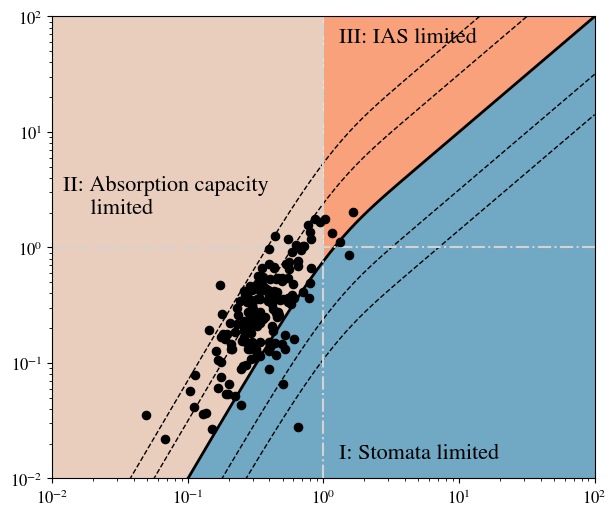

In [4]:
df_ = pandas_estimate_parameters(df, column_map=column_map)
plot_1d_phase_space(df_)

### Plot data in figure 3A - assess IAS gradients

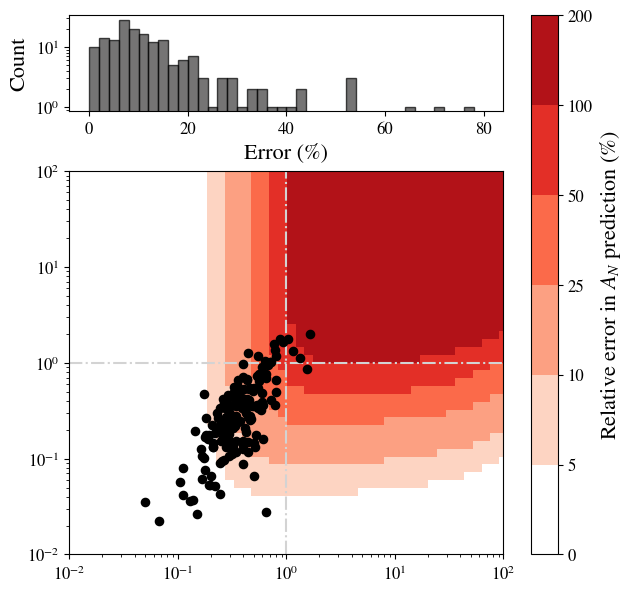

Error statistics:
Mean error: 15.90%
Median error: 10.26%
Max error: 139.71%
Min error: 0.71%
Percentage of errors below 10%: 48.85%




In [5]:
# load IAS gradients error map - found in ./heatmaps/ in the provided module
error_ias_gradients = load_error_map(f"heatmaps/gradients/3Dv0D_{STOMATAL_DENSITY_TO_MESOPHYLL_THICKNESS}.txt")
error_ias_gradients_data = plot_error_map(df_, error_ias_gradients, base_color="Reds")
df_["error_ias_gradients"] = error_ias_gradients_data

print("Error statistics:")
describe_errors(error_ias_gradients_data, ERROR_THRESHOLD)


### Plot data in figure 3B - assess lateral gradients

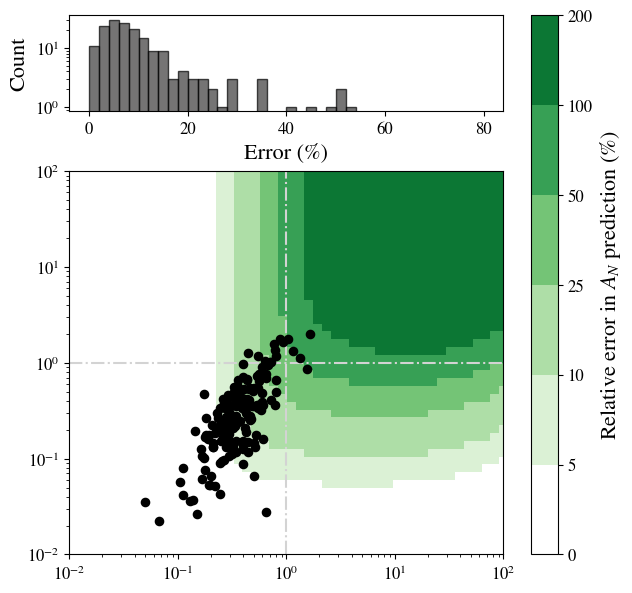

Error statistics:
Mean error: 10.99%
Median error: 7.50%
Max error: 80.09%
Min error: 0.67%
Percentage of errors below 10%: 64.37%




In [6]:
# load lateral gradients error map - found in ./heatmaps/ in the provided module
error_lateral_gradients = load_error_map(f"heatmaps/lateral/3Dv1D_{STOMATAL_DENSITY_TO_MESOPHYLL_THICKNESS}.txt")
error_lateral_gradients_data = plot_error_map(df_, error_lateral_gradients, base_color="Greens")
df_["error_lateral_gradients"] = error_lateral_gradients_data

print("Error statistics:")
describe_errors(error_lateral_gradients_data, ERROR_THRESHOLD)

### Plot data in figure 3C - sensitivity to heterogeneity

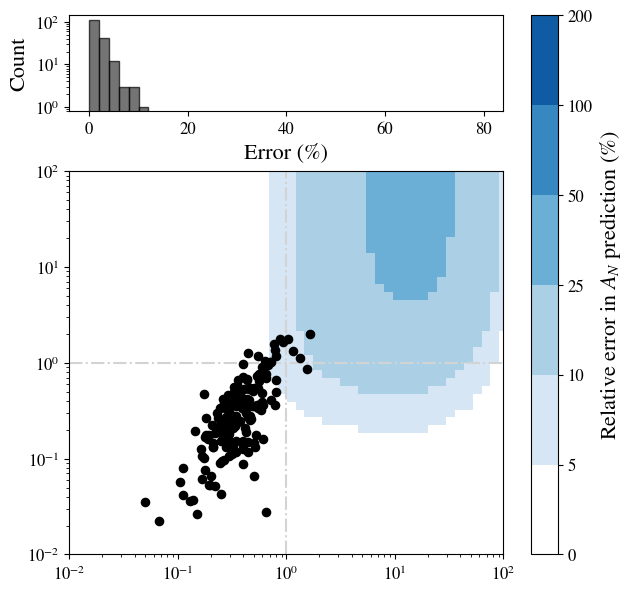

Error statistics:
Mean error: 2.01%
Median error: 1.48%
Max error: 11.66%
Min error: 0.01%
Percentage of errors below 10%: 99.43%




In [7]:
# load axial heterogeneity error map - found in ./heatmaps/ in the provided module
error_heterogeneity = load_error_map(f"heatmaps/heterogeneity/3D_typical_contrast_{CONTRAST:.2f}.txt")
error_heterogeneity_data = plot_error_map(df_, error_heterogeneity, base_color="Blues")
df_["error_heterogeneity"] = error_heterogeneity_data

print("Error statistics:")
describe_errors(error_heterogeneity_data, ERROR_THRESHOLD)

### Plot data in figure 4

Percentage of data points with error from omitting IAS CO2 gradients less than 10%: 48.85%
Percentage of data points with error from omitting lateral gradients less than 10%: 64.37%
Percentage of data points with error from omitting heterogeneity less than 10%: 99.43%


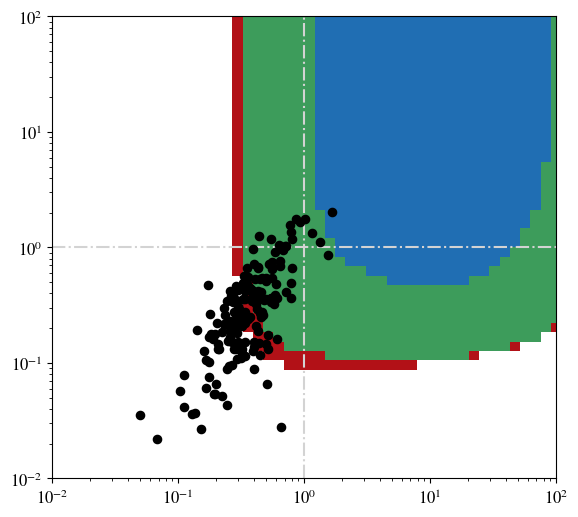

In [8]:
plot_decision_boundaries(df_, error_ias_gradients, error_lateral_gradients, error_heterogeneity, ERROR_THRESHOLD)


### Get mapped parameters and errors as a new .csv file

In [9]:
if SAVE_UPDATED_DATAFILE:
    df_.to_csv(PATH_TO_UPDATED_DATAFILE, index=False, sep=";", decimal=",") # choose different decimal and separator if prefered

df_.head(15)

,species,family,plant_functional_type,An,mesophyll_thickness,stomatal_conductance,substomatal_conc,compensation_point,ias_conductance,tau,gamma,error_ias_gradients,error_lateral_gradients,error_heterogeneity
0,Abies alba,Pinaceae,evergreen gymnosperms,7.985494,362.714316,0.138630,170.599173,41.466983,0.726732,0.424606,0.381516,15.979141,11.479700,2.234590
1,Abies alba,Pinaceae,evergreen gymnosperms,6.553428,488.461835,0.120659,208.705501,45.905071,0.560119,0.388444,0.430834,14.736649,10.626360,2.054606
2,Abies pinsapo,Pinaceae,evergreen gymnosperms,15.426869,954.705501,0.097224,255.058681,47.718100,0.096414,1.659336,2.016793,139.707206,80.092293,11.657106
3,Abies pinsapo,Pinaceae,evergreen gymnosperms,12.356595,455.106014,0.066814,158.570739,46.626593,0.155397,1.553647,0.859916,77.534862,49.984887,8.775960
4,Abies pinsapo,Pinaceae,evergreen gymnosperms,14.301041,874.293486,0.068918,239.351450,40.675950,0.123935,1.334601,1.112165,84.197388,52.861286,8.749826
5,Abies pinsapo,Pinaceae,evergreen gymnosperms,15.391478,780.018975,0.100316,266.327828,52.003318,0.151446,1.156630,1.324773,82.193420,51.299878,8.289067
6,Acer mono,Sapindaceae,deciduous angiosperms,11.691863,143.584567,0.202321,181.293488,31.945584,1.050597,0.395899,0.385154,14.660032,10.572696,2.054184
7,Acer palmatum,Sapindaceae,deciduous angiosperms,10.074639,140.612041,0.212005,254.781993,38.642046,0.760109,0.357525,0.557829,13.699173,9.918253,1.897507
8,Acer rufinerve,Sapindaceae,deciduous angiosperms,5.440835,234.206862,0.088142,312.019862,28.485378,1.088963,0.188839,0.161882,4.278687,3.266483,0.570178
9,Arabidopsis thaliana,Brassicaceae,C3 annual herbaceous,10.078067,122.719331,0.243450,294.652077,53.858427,1.048381,0.286380,0.464430,9.431036,6.946462,1.315109
